In [1]:
import os
import io
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from noawclg.main import get_noaa_data as gnd

from __future__ import annotations

import argparse
import logging
import time
import warnings
from pathlib import Path
from typing import Callable

import cartopy.feature as cfeature
import cmocean
import matplotlib.ticker as mticker
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
import pandas as pd


In [ ]:
VARS_NEEDED = ["prmsl", "prate", "r2", "cwat", "u", "v", "t2m"]
HOURS = list(range(0, 49, 3))  # primeiras 48h para carga inicial mais rapida
data = gnd(date="16/04/2026", keys=VARS_NEEDED, hours=HOURS)

In [7]:
"""
Funções de animação para dados GFS 0.25 com salvamento local de frames.
Estrutura de diretórios: frames/{var}/{run_date}/{cycle_str}/frame_NNN.png
"""

# ───────────────────────────────────────────────
# Utilitários internos
# ───────────────────────────────────────────────

def _gfs_meta(ds, var: str) -> tuple[str, str]:
    """
    Extrai data de rodada e ciclo (00z/06z/12z/18z) do dataset GFS.
    Tenta os atributos padrão do xarray/cfgrib; cai para inferência pelo
    primeiro passo de tempo se os atributos não estiverem presentes.

    Retorna: (run_date_str, cycle_str)  ex.: ("20250410", "00z")
    """


    # Tenta atributos globais típicos de arquivos GRIB2 / xarray
    for attr in ("history", "GRIB_dataDate", "initial_time", "reftime"):
        val = ds.attrs.get(attr) or ds[var].attrs.get(attr)
        if val:
            break

    # Preferência: coordenada 'time' ou 'valid_time' como ponto de ancoragem
    try:
        t0 = pd.Timestamp(ds[var].time.values[0])
        step0_h = int(ds[var].step.values[0] / np.timedelta64(1, "h")) if "step" in ds[var].coords else 0
        run_time = t0 - pd.Timedelta(hours=step0_h)
    except Exception:
        run_time = pd.Timestamp.now()

    run_date_str = run_time.strftime("%Y%m%d")
    # Ciclo GFS: 00 / 06 / 12 / 18
    cycle_str = f"{(run_time.hour // 6) * 6:02d}z"
    return run_date_str, cycle_str


def _frames_dir(var: str, run_date: str, cycle: str, base: str = "frames") -> str:
    """Monta e cria o diretório de frames."""
    path = os.path.join(base, var, run_date, cycle)
    os.makedirs(path, exist_ok=True)
    return path


def _frame_path(frames_dir: str, tidx: int) -> str:
    return os.path.join(frames_dir, f"frame_{tidx:03d}.png")


# ───────────────────────────────────────────────
# 2. IMAGEIO
# ───────────────────────────────────────────────

import imageio.v2 as imageio


def animate_ortho(
    ds,
    var: str,
    central_point: tuple,
    output: str = "output.mp4",
    fps: int = 6,
    step: int = 1,
    dpi: int = 120,
    figsize: tuple = (8, 8),
):
    """
    Salva cada frame em disco e depois faz streaming para o writer do imageio,
    sem manter imagens na memória entre frames.
    """
    run_date, cycle = _gfs_meta(ds, var)
    fdir = _frames_dir(var, run_date, cycle)

    n_frames = len(ds[var].time)
    proj = ccrs.Orthographic(*central_point)
    norm = BoundaryNorm(TEMP_LEVELS, ncolors=TEMP_CMAP.N, clip=True)

    # Passo 1 — renderizar frames ausentes para disco
    for tidx in range(n_frames):
        fpath = _frame_path(fdir, tidx)
        if not os.path.exists(fpath):
            lat, lon, t2m, time = _get(ds, var, time_idx=tidx, step=step)

            fig, ax = plt.subplots(
                figsize=figsize,
                subplot_kw={"projection": proj},
                facecolor="#0d1117",
                dpi=dpi,
            )
            ax.set_global()
            _add_features(ax, 0.5)
            cf = ax.pcolormesh(
                lon, lat, t2m,
                cmap=TEMP_CMAP, norm=norm,
                transform=ccrs.PlateCarree(), zorder=1,
            )
            ax.contour(
                lon[::3], lat[::3], t2m[::3, ::3],
                levels=TEMP_LEVELS[::5],
                colors="white", linewidths=0.25, alpha=0.4,
                transform=ccrs.PlateCarree(), zorder=2,
            )
            _colorbar(fig, cf, ax, "Temperatura (°C)")
            _title(ax, "T2m — Global Ortho", _run_label(time))
            fig.tight_layout()
            fig.savefig(fpath, format="png", dpi=dpi)
            plt.close(fig)

        print(f"  frame {tidx + 1}/{n_frames}  →  {fpath}", end="\r")

    print()

    # Passo 2 — montar vídeo lendo frames do disco um a um
    writer_kwargs = {"fps": fps}
    if output.endswith(".mp4"):
        writer_kwargs["codec"] = "libx264"
        writer_kwargs["quality"] = 8

    with imageio.get_writer(output, **writer_kwargs) as writer:
        for tidx in range(n_frames):
            fpath = _frame_path(fdir, tidx)
            writer.append_data(imageio.imread(fpath))

    print(f"Salvo em: {output}")



In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import imageio
from matplotlib.colors import BoundaryNorm


# ── module-level defaults (overridable per-instance via set_* methods) ────────

TEMP_CMAP   = cmocean.cm.thermal
TEMP_LEVELS = np.arange(-20, 50, 2)

PRES_CMAP   = plt.cm.RdBu_r
PRES_LEVELS = np.arange(960, 1040, 2)

plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#0d1117",
    "text.color":       "#e6edf3",
    "axes.labelcolor":  "#e6edf3",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "font.family":      "monospace",
    "axes.titlepad":    10,
})


# ══════════════════════════════════════════════════════════════════════════════
# Module-level map helpers
# ══════════════════════════════════════════════════════════════════════════════

def _get(ds, var: str, time_idx: int = 0, step: int = 2):
    da = ds[var][time_idx]
    return (
        da.latitude.values[::step],
        da.longitude.values[::step],
        da.values[::step, ::step],
        da.time.values,
    )


def _add_features(ax: plt.Axes, lw: float = 0.4) -> None:
    ax.add_feature(cfeature.LAND,      facecolor="#1c2128", edgecolor="none",        zorder=0)
    ax.add_feature(cfeature.COASTLINE, edgecolor="#58a6ff", linewidth=lw,            zorder=3)
    ax.add_feature(cfeature.BORDERS,   edgecolor="#484f58", linewidth=lw * 0.7,
                   linestyle="--", zorder=3)


def _add_gridlines(ax: plt.Axes, proj) -> None:
    draw = isinstance(proj, (ccrs.Mercator, ccrs.PlateCarree))
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(), draw_labels=draw,
        linewidth=0.3, color="#21262d", alpha=0.8, linestyle="--", zorder=2,
    )
    gl.top_labels   = False
    gl.right_labels = False
    gl.xlocator     = mticker.MultipleLocator(10)
    gl.ylocator     = mticker.MultipleLocator(10)
    gl.xlabel_style = {"size": 6, "color": "#8b949e"}
    gl.ylabel_style = {"size": 6, "color": "#8b949e"}


def _colorbar(fig, cf, ax, label: str, orientation: str = "horizontal") -> None:
    cb = fig.colorbar(cf, ax=ax, orientation=orientation,
                      pad=0.03, fraction=0.03, shrink=0.85)
    cb.set_label(label, fontsize=8, color="#8b949e")
    cb.ax.tick_params(labelsize=7, colors="#8b949e")
    cb.outline.set_edgecolor("#30363d")


def _title(ax, main: str, sub: str = "") -> None:
    ax.set_title(main, fontsize=10, fontweight="bold",
                 color="#e6edf3", loc="left", pad=6)
    if sub:
        ax.set_title(sub, fontsize=7, color="#8b949e", loc="right", pad=6)


def _run_label(time_val) -> str:
    return f"GFS — {time_val}"


def _gfs_meta(ds, var: str):
    """Return (run_date_str, cycle_str) from dataset attributes."""
    run_date = str(ds.attrs.get("run_date", "unknown"))
    cycle    = str(ds.attrs.get("cycle",    "00z"))
    return run_date, cycle


def _frames_dir(var: str, run_date: str, cycle: str) -> str:
    path = os.path.join("frames", f"{var}_{run_date}_{cycle}")
    os.makedirs(path, exist_ok=True)
    return path


def _frame_path(fdir: str, tidx: int) -> str:
    return os.path.join(fdir, f"frame_{tidx:04d}.png")


# ══════════════════════════════════════════════════════════════════════════════
# OrthoAnimator
# ══════════════════════════════════════════════════════════════════════════════

class OrthoAnimator:
    """
    Renders an orthographic animation of a GFS variable.

    Quick start
    -----------
    anim = OrthoAnimator(ds, "t2m")
    anim.set_output("output.mp4")
    anim.set_rotation(lon_start=-90, lon_end=-20, lat_start=-5, lat_end=-20)
    anim.set_rotation_stop(fraction=0.65)
    anim.animate()

    Static snapshot
    ---------------
    anim.plot(time_idx=0, save="snapshot.png")
    anim.plot(time_idx=0)          # opens interactive window
    """

    # ── class-level defaults ──────────────────────────────────────────────────
    _OUTPUT_DEFAULT  = "output.mp4"
    _FPS_DEFAULT     = 6
    _STEP_DEFAULT    = 1
    _DPI_DEFAULT     = 120
    _FIGSIZE_DEFAULT = (8, 8)

    def __init__(self, ds, var: str, central_point: tuple = (-45.0, -15.0)):
        self._ds            = ds
        self._var           = var
        self._central_point = central_point

        # output options
        self._output  = self._OUTPUT_DEFAULT
        self._fps     = self._FPS_DEFAULT
        self._step    = self._STEP_DEFAULT
        self._dpi     = self._DPI_DEFAULT
        self._figsize = self._FIGSIZE_DEFAULT

        # colormap / levels (start from module defaults; overridable per instance)
        self._cmap   = TEMP_CMAP
        self._levels = TEMP_LEVELS
        self._cbar_label = "Temperature (°C)"
        self._plot_title = "T2m — Global Ortho"

        # rotation (None = no rotation)
        self._lon_start     = None
        self._lat_start     = None
        self._lon_end       = None
        self._lat_end       = None
        self._stop_frame    = None
        self._stop_fraction = None

    # ── output options ────────────────────────────────────────────────────────

    def set_output(self, path: str) -> "OrthoAnimator":
        """Output file path (.mp4 or .gif)."""
        self._output = path
        return self

    def set_fps(self, fps: int) -> "OrthoAnimator":
        """Frames per second."""
        self._fps = fps
        return self

    def set_step(self, step: int) -> "OrthoAnimator":
        """Spatial decimation factor (1 = no decimation)."""
        self._step = step
        return self

    def set_dpi(self, dpi: int) -> "OrthoAnimator":
        """Figure resolution in dots per inch."""
        self._dpi = dpi
        return self

    def set_figsize(self, w: float, h: float) -> "OrthoAnimator":
        """Figure size in inches (width, height)."""
        self._figsize = (w, h)
        return self

    # ── colormap / levels options ─────────────────────────────────────────────

    def set_cmap(self, cmap) -> "OrthoAnimator":
        """
        Override the colormap used for the pcolormesh fill.

        Accepts any matplotlib-compatible colormap object or name string.

        Examples
        --------
        anim.set_cmap(cmocean.cm.thermal)
        anim.set_cmap("RdBu_r")
        anim.set_cmap(plt.cm.viridis)
        """
        self._cmap = plt.get_cmap(cmap) if isinstance(cmap, str) else cmap
        return self

    def set_levels(self, levels) -> "OrthoAnimator":
        """
        Override the contour / BoundaryNorm levels.

        Accepts a 1-D array-like of level boundaries.

        Examples
        --------
        anim.set_levels(np.arange(960, 1040, 2))          # pressure
        anim.set_levels(np.linspace(-30, 45, 40))          # custom temperature
        """
        self._levels = np.asarray(levels)
        return self

    def set_cbar_label(self, label: str) -> "OrthoAnimator":
        """Label shown on the colorbar."""
        self._cbar_label = label
        return self

    def set_plot_title(self, title: str) -> "OrthoAnimator":
        """Main title shown on each frame / static plot."""
        self._plot_title = title
        return self

    def use_pressure_defaults(self) -> "OrthoAnimator":
        """
        Convenience shortcut: switch cmap and levels to the module-level
        pressure defaults (PRES_CMAP / PRES_LEVELS) in one call.
        """
        self._cmap       = PRES_CMAP
        self._levels     = PRES_LEVELS
        self._cbar_label = "Sea-level pressure (hPa)"
        self._plot_title = "MSLP — Global Ortho"
        return self

    def use_temperature_defaults(self) -> "OrthoAnimator":
        """Switch back to module-level temperature defaults."""
        self._cmap       = TEMP_CMAP
        self._levels     = TEMP_LEVELS
        self._cbar_label = "Temperature (°C)"
        self._plot_title = "T2m — Global Ortho"
        return self

    # ── rotation options ──────────────────────────────────────────────────────

    def set_rotation(
        self,
        lon_start: float,
        lon_end: float,
        lat_start: float | None = None,
        lat_end: float | None = None,
    ) -> "OrthoAnimator":
        """
        Define the camera arc from (lon_start, lat_start) to (lon_end, lat_end).

        If lat_start / lat_end are omitted, the latitude of central_point is
        used as a fixed value throughout the rotation.
        """
        self._lon_start = lon_start
        self._lon_end   = lon_end
        self._lat_start = lat_start if lat_start is not None else self._central_point[1]
        self._lat_end   = lat_end   if lat_end   is not None else self._central_point[1]
        return self

    def set_rotation_stop(
        self,
        frame: int | None = None,
        fraction: float | None = None,
    ) -> "OrthoAnimator":
        """
        Frame at which the rotation ends and the camera freezes on the end point.

        Provide either `frame` (absolute index) **or** `fraction` (0.0–1.0
        relative to total frames).  The value is resolved to an absolute index
        inside animate(), once the total frame count is known.
        """
        if frame is not None and fraction is not None:
            raise ValueError("Provide 'frame' or 'fraction', not both.")
        if fraction is not None:
            if not 0.0 < fraction < 1.0:
                raise ValueError("fraction must be strictly between 0 and 1.")
            self._stop_fraction = fraction
            self._stop_frame    = None
        else:
            self._stop_frame    = frame
            self._stop_fraction = None
        return self

    # ── internal helpers ──────────────────────────────────────────────────────

    def _resolve_stop_frame(self, n_frames: int) -> int:
        """Convert fraction → absolute index (called once per animate())."""
        if self._stop_fraction is not None:
            return max(1, int(round(self._stop_fraction * n_frames)))
        if self._stop_frame is not None:
            return self._stop_frame
        return n_frames  # no stop defined → rotate through entire video

    def _rotation_at(self, tidx: int, stop: int) -> tuple[float, float]:
        """
        Return the (lon, lat) of the camera centre for frame `tidx`.

        Before `stop`  → linear interpolation between start and end of rotation.
        From `stop` on → freeze at the end point (or central_point if no
                          rotation was configured).
        """
        if self._lon_start is None:
            return self._central_point

        if tidx >= stop:
            return (self._lon_end, self._lat_end)

        t   = tidx / stop
        lon = self._lon_start + t * (self._lon_end - self._lon_start)
        lat = self._lat_start + t * (self._lat_end - self._lat_start)
        return (lon, lat)

    def _build_axes(self, central: tuple) -> tuple[plt.Figure, plt.Axes]:
        """Create and return a (fig, ax) pair with the orthographic projection."""
        proj = ccrs.Orthographic(*central)
        fig, ax = plt.subplots(
            figsize=self._figsize,
            subplot_kw={"projection": proj},
            facecolor="#0d1117",
            dpi=self._dpi,
        )
        ax.set_global()
        _add_features(ax, 0.5)
        return fig, ax

    def _draw_field(
        self,
        fig: plt.Figure,
        ax: plt.Axes,
        lat, lon, field, time_val,
    ) -> None:
        """Draw pcolormesh + contour + colorbar + title onto an existing axes."""
        norm = BoundaryNorm(self._levels, ncolors=self._cmap.N, clip=True)

        cf = ax.pcolormesh(
            lon, lat, field,
            cmap=self._cmap, norm=norm,
            transform=ccrs.PlateCarree(), zorder=1,
        )
        ax.contour(
            lon[::3], lat[::3], field[::3, ::3],
            levels=self._levels[::5],
            colors="white", linewidths=0.25, alpha=0.4,
            transform=ccrs.PlateCarree(), zorder=2,
        )
        _colorbar(fig, cf, ax, self._cbar_label)
        _title(ax, self._plot_title, _run_label(time_val))

    def _render_frame(self, tidx: int, fpath: str, central: tuple) -> None:
        """Render a single frame and save it to disk."""
        lat, lon, field, time_val = _get(
            self._ds, self._var, time_idx=tidx, step=self._step
        )
        fig, ax = self._build_axes(central)
        self._draw_field(fig, ax, lat, lon, field, time_val)
        fig.tight_layout()
        fig.savefig(fpath, format="png", dpi=self._dpi)
        plt.close(fig)

    def _write_video(self, fdir: str, n_frames: int) -> None:
        """Assemble the video by reading frames from disk one at a time."""
        writer_kwargs: dict = {"fps": self._fps}
        if self._output.endswith(".mp4"):
            writer_kwargs["codec"]   = "libx264"
            writer_kwargs["quality"] = 8

        with imageio.get_writer(self._output, **writer_kwargs) as writer:
            for tidx in range(n_frames):
                writer.append_data(imageio.imread(_frame_path(fdir, tidx)))

    # ── public entry points ───────────────────────────────────────────────────

    def plot(
        self,
        time_idx: int = 0,
        central_point: tuple | None = None,
        save: str | None = None,
    ) -> "OrthoAnimator":
        """
        Render a single static frame and either save it or show it interactively.

        Parameters
        ----------
        time_idx : int
            Time index to plot (default 0 = first time step).
        central_point : tuple, optional
            Override (lon, lat) for this plot only. Falls back to the
            instance's central_point if not supplied.
        save : str, optional
            File path to save the figure (e.g. "snapshot.png").
            If None, plt.show() is called instead.

        Examples
        --------
        anim.plot(time_idx=6)
        anim.plot(time_idx=0, central_point=(-60, -20), save="fig.png")
        """
        centre = central_point if central_point is not None else self._central_point
        lat, lon, field, time_val = _get(
            self._ds, self._var, time_idx=time_idx, step=self._step
        )
        fig, ax = self._build_axes(centre)
        self._draw_field(fig, ax, lat, lon, field, time_val)
        fig.tight_layout()

        if save:
            fig.savefig(save, dpi=self._dpi, bbox_inches="tight")
            print(f"Saved: {save}")
            plt.close(fig)
        else:
            plt.show()

        return self

    def animate(self) -> "OrthoAnimator":
        """
        Step 1 — render missing frames to disk.
        Step 2 — assemble the video from the PNG files.
        """
        run_date, cycle = _gfs_meta(self._ds, self._var)
        fdir     = _frames_dir(self._var, run_date, cycle)
        n_frames = len(self._ds[self._var].time)
        stop     = self._resolve_stop_frame(n_frames)

        for tidx in range(n_frames):
            fpath   = _frame_path(fdir, tidx)
            central = self._rotation_at(tidx, stop)

            if not os.path.exists(fpath):
                self._render_frame(tidx, fpath, central)

            print(f"  frame {tidx + 1}/{n_frames}  →  {fpath}", end="\r")

        print()
        self._write_video(fdir, n_frames)
        print(f"Saved: {self._output}")
        return self

In [6]:
oa = OrthoAnimator(data._ds, "prmsl")
oa.use_pressure_defaults()
oa.set_rotation(lon_start=-120, lon_end=-40)
oa.set_rotation_stop(fraction=0.6)
oa.set_output("prmsl.mp4")
oa.set_fps(14)
oa.plot(time_idx=0, save="mslp_snapshot.png")   # static check first
oa.animate()

Saved: mslp_snapshot.png
  frame 129/129  →  frames/prmsl_20260416_00z/frame_0128.png


/tmp/ipykernel_15660/1890990957.py:375: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(_frame_path(fdir, tidx)))


Saved: prmsl.mp4


In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import imageio
from matplotlib.colors import BoundaryNorm


# ── module-level defaults (overridable per-instance via set_* methods) ────────

TEMP_CMAP   = cmocean.cm.thermal
TEMP_LEVELS = np.arange(-20, 50, 2)

PRES_CMAP   = plt.cm.RdBu_r
PRES_LEVELS = np.arange(960, 1040, 2)

# ── per-variable plotting presets ─────────────────────────────────────────────
#
# Keys match GFS variable names. Each entry defines:
#   cmap        : colormap object or name
#   levels      : contour / BoundaryNorm boundaries
#   cbar_label  : colorbar axis label
#   plot_title  : left-side frame title
#
# Add or override entries here to extend support to new variables without
# touching any instance code.

VARIABLE_PRESETS = {
    # ── 2-metre temperature (°C) ──────────────────────────────────────────────
    "t2m": {
        "cmap":       cmocean.cm.thermal,
        "levels":     np.arange(-20, 50, 2),
        "cbar_label": "2-m Temperature (°C)",
        "plot_title": "2-m Temperature — Global Ortho",
    },

    # ── Mean sea-level pressure (hPa) ────────────────────────────────────────
    "prmsl": {
        "cmap":       plt.cm.RdBu_r,
        "levels":     np.arange(960, 1044, 2),
        "cbar_label": "MSLP (hPa)",
        "plot_title": "Mean Sea-Level Pressure — Global Ortho",
    },

    # ── Precipitation rate (mm h⁻¹) ──────────────────────────────────────────
    # Logarithmic-style levels capture both drizzle and heavy rain.
    # cmocean.cm.rain gives an intuitive white → dark-blue palette.
    "prate": {
        "cmap":       cmocean.cm.rain,
        "levels":     np.array([0, 0.1, 0.25, 0.5, 1, 2, 4, 8, 16, 32, 64]),
        "cbar_label": "Precipitation rate (mm h⁻¹)",
        "plot_title": "Precipitation Rate — Global Ortho",
    },

    # ── 2-metre relative humidity (%) ────────────────────────────────────────
    # cmocean.cm.haline maps dry (low) to moist (high) naturally.
    "r2": {
        "cmap":       cmocean.cm.haline,
        "levels":     np.arange(0, 105, 5),
        "cbar_label": "2-m Relative Humidity (%)",
        "plot_title": "2-m Relative Humidity — Global Ortho",
    },

    # ── Column cloud water (kg m⁻²) ──────────────────────────────────────────
    # Gray-to-white palette echoes how cloud cover looks from space.
    "cwat": {
        "cmap":       cmocean.cm.ice,
        "levels":     np.array([0, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0,
                                 1.5, 2.0, 3.0, 5.0]),
        "cbar_label": "Cloud Water (kg m⁻²)",
        "plot_title": "Column Cloud Water — Global Ortho",
    },

    # ── Forecast hour (meta / index field) ───────────────────────────────────
    # Rarely plotted as a spatial field; sensible fallback provided anyway.
    "forecast_hour": {
        "cmap":       plt.cm.viridis,
        "levels":     np.arange(0, 241, 6),
        "cbar_label": "Forecast Hour",
        "plot_title": "Forecast Hour — Global Ortho",
    },
}


def list_variable_presets() -> None:
    """Print all variable presets and their associated colormaps / level ranges."""
    print(f"{'Variable':<16}  {'Cmap':<22}  {'Levels':<30}  Label")
    print("-" * 100)
    for key, p in VARIABLE_PRESETS.items():
        lvl = p["levels"]
        lvl_str = f"{lvl[0]}…{lvl[-1]} ({len(lvl)} steps)"
        cmap_name = getattr(p["cmap"], "name", str(p["cmap"]))
        print(f"{key:<16}  {cmap_name:<22}  {lvl_str:<30}  {p['cbar_label']}")


# ── quality presets ───────────────────────────────────────────────────────────

QUALITY_PRESETS = {
    "sd": {
        "dpi":     72,
        "figsize": (8, 8),
        "fps":     6,
        "codec":   "libx264",
        "quality": 6,
        "description": "Standard Definition — fast render, small file",
    },
    "hd": {
        "dpi":     120,
        "figsize": (10, 10),
        "fps":     24,
        "codec":   "libx264",
        "quality": 8,
        "description": "Full HD (1080p-range) — balanced quality and speed",
    },
    "4k": {
        "dpi":     220,
        "figsize": (17.07, 17.07),   # 17.07 in × 220 dpi ≈ 3756 px → ~3840 px after tight layout
        "fps":     30,
        "codec":   "libx264",
        "quality": 10,
        "description": "Ultra HD 4K — maximum quality, large file and slow render",
    },
    "4k_60": {
        "dpi":     220,
        "figsize": (17.07, 17.07),
        "fps":     60,
        "codec":   "libx264",
        "quality": 10,
        "description": "Ultra HD 4K @ 60 fps — silky smooth, very large file",
    },
}


plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#0d1117",
    "text.color":       "#e6edf3",
    "axes.labelcolor":  "#e6edf3",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "font.family":      "monospace",
    "axes.titlepad":    10,
})


# ══════════════════════════════════════════════════════════════════════════════
# Module-level map helpers
# ══════════════════════════════════════════════════════════════════════════════

def _get(ds, var: str, time_idx: int = 0, step: int = 2):
    da = ds[var][time_idx]
    return (
        da.latitude.values[::step],
        da.longitude.values[::step],
        da.values[::step, ::step],
        da.time.values,
    )


def _add_features(ax: plt.Axes, lw: float = 0.4) -> None:
    ax.add_feature(cfeature.LAND,      facecolor="#1c2128", edgecolor="none",        zorder=0)
    ax.add_feature(cfeature.COASTLINE, edgecolor="#58a6ff", linewidth=lw,            zorder=3)
    ax.add_feature(cfeature.BORDERS,   edgecolor="#484f58", linewidth=lw * 0.7,
                   linestyle="--", zorder=3)


def _font_scale(dpi: int, base_dpi: int = 120) -> float:
    """
    Return a multiplier so that text stays visually proportional across DPIs.

    The reference point is the default HD preset (120 dpi = scale 1.0).
    At 220 dpi (4K) this gives ~1.83×, making labels clearly readable on a
    high-resolution render without becoming oversized in SD previews.

    The square-root dampening prevents text from growing as fast as pixels,
    which matches how human perception works on large screens.

        scale = sqrt(dpi / base_dpi)

    Examples
    --------
    dpi= 72  → scale ≈ 0.77   (SD — slightly smaller text)
    dpi=120  → scale = 1.00   (HD — reference)
    dpi=220  → scale ≈ 1.35   (4K — noticeably larger, still balanced)
    dpi=300  → scale ≈ 1.58   (print — comfortable for close-up viewing)
    """
    return (dpi / base_dpi) ** 0.5


def _add_gridlines(ax: plt.Axes, proj, scale: float = 1.0) -> None:
    draw = isinstance(proj, (ccrs.Mercator, ccrs.PlateCarree))
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(), draw_labels=draw,
        linewidth=0.3 * scale, color="#21262d", alpha=0.8, linestyle="--", zorder=2,
    )
    gl.top_labels   = False
    gl.right_labels = False
    gl.xlocator     = mticker.MultipleLocator(10)
    gl.ylocator     = mticker.MultipleLocator(10)
    gl.xlabel_style = {"size": round(6 * scale, 1), "color": "#8b949e"}
    gl.ylabel_style = {"size": round(6 * scale, 1), "color": "#8b949e"}


def _colorbar(fig, cf, ax, label: str, orientation: str = "horizontal",
              scale: float = 1.0) -> None:
    cb = fig.colorbar(cf, ax=ax, orientation=orientation,
                      pad=0.03, fraction=0.03, shrink=0.85)
    cb.set_label(label, fontsize=round(8 * scale, 1), color="#8b949e")
    cb.ax.tick_params(labelsize=round(7 * scale, 1), colors="#8b949e")
    cb.outline.set_edgecolor("#30363d")


def _title(ax, main: str, sub: str = "", scale: float = 1.0) -> None:
    ax.set_title(main, fontsize=round(10 * scale, 1), fontweight="bold",
                 color="#e6edf3", loc="left", pad=6 * scale)
    if sub:
        ax.set_title(sub, fontsize=round(7 * scale, 1), color="#8b949e",
                     loc="right", pad=6 * scale)


def _run_label(time_val) -> str:
    return f"GFS — {time_val}"


def _gfs_meta(ds, var: str):
    """Return (run_date_str, cycle_str) from dataset attributes."""
    run_date = str(ds.attrs.get("run_date", "unknown"))
    cycle    = str(ds.attrs.get("cycle",    "00z"))
    return run_date, cycle


def _frames_dir(var: str, run_date: str, cycle: str) -> str:
    path = os.path.join("frames", f"{var}_{run_date}_{cycle}")
    os.makedirs(path, exist_ok=True)
    return path


def _frame_path(fdir: str, tidx: int) -> str:
    return os.path.join(fdir, f"frame_{tidx:04d}.png")


def _interp_field_value(lat_arr, lon_arr, field, pos: tuple) -> float:
    """
    Return the field value at the grid point nearest to pos=(lat, lon).

    Uses nearest-neighbour lookup — no interpolation weights, which keeps
    the call fast inside a per-frame render loop.

    Parameters
    ----------
    lat_arr : 1-D array  Latitude grid values (degrees).
    lon_arr : 1-D array  Longitude grid values (degrees).
    field   : 2-D array  Data values on the (lat, lon) grid.
    pos     : (lat, lon) Target geographic position in decimal degrees.

    Returns
    -------
    float   Scalar field value at the nearest grid point.
    """
    lat_target, lon_target = pos
    i = int(np.argmin(np.abs(lat_arr - lat_target)))
    j = int(np.argmin(np.abs(lon_arr - lon_target)))
    return float(field[i, j])


def list_quality_presets() -> None:
    """Print all available quality presets and their settings."""
    print(f"{'Preset':<10}  {'DPI':<5}  {'Figsize (in)':<16}  {'FPS':<5}  {'Codec':<10}  Description")
    print("-" * 90)
    for name, p in QUALITY_PRESETS.items():
        w, h = p["figsize"]
        px_w = int(w * p["dpi"])
        px_h = int(h * p["dpi"])
        print(
            f"{name:<10}  {p['dpi']:<5}  {w:.1f}×{h:.1f} ({px_w}×{px_h} px)"
            f"{'':>2}  {p['fps']:<5}  {p['codec']:<10}  {p['description']}"
        )


# ══════════════════════════════════════════════════════════════════════════════
# OrthoAnimator
# ══════════════════════════════════════════════════════════════════════════════

class OrthoAnimator:
    """
    Renders an orthographic animation of a GFS variable.

    Supported variables (auto-configured on construction)
    -------------------------------------------------------
    "t2m"           2-metre temperature (°C)
    "prmsl"         Mean sea-level pressure (hPa)
    "prate"         Precipitation rate (mm h⁻¹)
    "r2"            2-metre relative humidity (%)
    "cwat"          Column cloud water (kg m⁻²)
    "forecast_hour" Forecast hour index

    Any variable not in the table falls back to temperature defaults.
    Call use_variable_defaults(key) at any time to switch presets.

    Quick start
    -----------
    anim = OrthoAnimator(ds, "t2m")
    anim.set_output("output.mp4")
    anim.set_rotation(lon_start=-90, lon_end=-20, lat_start=-5, lat_end=-20)
    anim.set_rotation_stop(fraction=0.65)
    anim.animate()

    4K output
    ---------
    anim.set_quality("4k")          # preset: dpi=220, figsize=17×17 in, fps=30
    anim.set_quality("4k_60")       # same pixels, 60 fps
    anim.set_quality("hd")          # Full-HD range, fps=24
    anim.set_quality("sd")          # lightweight preview

    Fine-grained control (overrides preset values individually)
    -----------------------------------------------------------
    anim.set_dpi(400)               # custom DPI
    anim.set_figsize(17.07, 17.07)  # ~3840 px wide at 225 dpi
    anim.set_fps(60)
    anim.set_video_quality(10)      # libx264 CRF-like quality, 0–10
    anim.set_codec("libx265")       # H.265 for smaller 4K files

    Map annotations
    ---------------
    anim.set_annotate("Juazeiro - BA %d°C", pos=(-9.4, -40.5))
    anim.set_annotate("Fortaleza %d°C",     pos=(-3.72, -38.54), color="#58a6ff")
    anim.clear_annotations()

    Static snapshot
    ---------------
    anim.plot(time_idx=0, save="snapshot.png")
    anim.plot(time_idx=0)          # opens interactive window
    """

    # ── class-level defaults ──────────────────────────────────────────────────
    _OUTPUT_DEFAULT        = "output.mp4"
    _FPS_DEFAULT           = 6
    _STEP_DEFAULT          = 1
    _DPI_DEFAULT           = 120
    _FIGSIZE_DEFAULT       = (8, 8)
    _CODEC_DEFAULT         = "libx264"
    _VIDEO_QUALITY_DEFAULT = 8      # imageio quality scale: 0 (worst) – 10 (best)

    def __init__(self, ds, var: str, central_point: tuple = (-45.0, -15.0)):
        self._ds            = ds
        self._var           = var
        self._central_point = central_point

        # output options
        self._output        = self._OUTPUT_DEFAULT
        self._fps           = self._FPS_DEFAULT
        self._step          = self._STEP_DEFAULT
        self._dpi           = self._DPI_DEFAULT
        self._figsize       = self._FIGSIZE_DEFAULT
        self._codec         = self._CODEC_DEFAULT
        self._video_quality = self._VIDEO_QUALITY_DEFAULT

        # ── auto-load variable preset (falls back to temperature defaults) ────
        self._apply_variable_preset(var, silent=False)

        # rotation (None = no rotation)
        self._lon_start     = None
        self._lat_start     = None
        self._lon_end       = None
        self._lat_end       = None
        self._stop_frame    = None
        self._stop_fraction = None

        # annotations
        self._annotations: list[dict] = []

    # ── variable preset helpers ───────────────────────────────────────────────

    def _apply_variable_preset(self, var: str, silent: bool = True) -> None:
        """
        Load cmap / levels / labels from VARIABLE_PRESETS[var].

        Falls back to temperature defaults when the key is not found and
        prints a one-line notice so the caller is aware.
        """
        if var in VARIABLE_PRESETS:
            p = VARIABLE_PRESETS[var]
            if not silent:
                print(f"Variable preset '{var}': {p['plot_title']}")
        else:
            p = VARIABLE_PRESETS["t2m"]
            print(
                f"[OrthoAnimator] No preset for '{var}' — "
                f"falling back to temperature defaults.  "
                f"Call use_variable_defaults(key) to override."
            )
        self._cmap       = p["cmap"]
        self._levels     = np.asarray(p["levels"])
        self._cbar_label = p["cbar_label"]
        self._plot_title = p["plot_title"]

    def use_variable_defaults(self, var: str | None = None) -> "OrthoAnimator":
        """
        Apply the plotting preset for `var` (or for the instance's own variable
        if `var` is omitted).

        Supported keys
        --------------
        "t2m"           2-metre temperature
        "prmsl"         Mean sea-level pressure
        "prate"         Precipitation rate
        "r2"            2-metre relative humidity
        "cwat"          Column cloud water
        "forecast_hour" Forecast hour

        Examples
        --------
        anim.use_variable_defaults()          # re-apply preset for current var
        anim.use_variable_defaults("prmsl")   # switch to pressure preset
        anim.use_variable_defaults("prate")   # switch to precipitation preset
        """
        key = var if var is not None else self._var
        self._apply_variable_preset(key, silent=False)
        return self

    # ── output options ────────────────────────────────────────────────────────

    def set_output(self, path: str) -> "OrthoAnimator":
        """Output file path (.mp4 or .gif)."""
        self._output = path
        return self

    def set_fps(self, fps: int) -> "OrthoAnimator":
        """
        Frames per second for the output video.

        Common values
        -------------
        6   → smooth enough for slow-moving weather fields (default)
        24  → cinematic HD
        30  → broadcast / streaming standard
        60  → ultra-smooth / gaming-grade (pairs well with 4K)
        """
        self._fps = fps
        return self

    def set_step(self, step: int) -> "OrthoAnimator":
        """Spatial decimation factor (1 = no decimation)."""
        self._step = step
        return self

    def set_dpi(self, dpi: int) -> "OrthoAnimator":
        """
        Figure resolution in dots per inch.

        Output pixel dimensions = figsize (inches) × dpi.

        Common targets
        --------------
        72   → screen preview / SD
        120  → Full-HD range  (default)
        150  → ~2K at 14-in figure
        220  → ~3840 px wide at 17.07-in figure (4K)
        300  → print-quality stills
        400+ → extreme close-up / poster crops
        """
        self._dpi = dpi
        return self

    def set_figsize(self, w: float, h: float) -> "OrthoAnimator":
        """
        Figure size in inches (width, height).

        Pixel output = (w × dpi, h × dpi).

        4K target: set_figsize(17.07, 17.07) with set_dpi(225)
        → 17.07 × 225 ≈ 3841 px per side.
        """
        self._figsize = (w, h)
        return self

    def set_codec(self, codec: str) -> "OrthoAnimator":
        """
        Video codec passed to imageio / ffmpeg.

        Common options
        --------------
        "libx264"   → H.264, widest compatibility (default)
        "libx265"   → H.265 / HEVC, ~40 % smaller files at same quality
                      (recommended for 4K to keep file sizes manageable)
        "vp9"       → open-source, good for web delivery
        "prores"    → Apple ProRes, lossless-ish, large files, ideal for editing
        """
        self._codec = codec
        return self

    def set_video_quality(self, quality: int) -> "OrthoAnimator":
        """
        Encoding quality passed to imageio (0 = worst, 10 = best).

        Higher values produce larger files but sharper detail — matters
        most at 4K where compression artefacts are more visible.

        Recommended values
        ------------------
        6   → SD / draft renders
        8   → HD (default)
        10  → 4K final output
        """
        if not 0 <= quality <= 10:
            raise ValueError("quality must be between 0 and 10.")
        self._video_quality = quality
        return self

    def set_quality(self, preset: str) -> "OrthoAnimator":
        """
        Apply a named quality preset in one call.

        Available presets (call list_quality_presets() to print them)
        --------------------------------------------------------------
        "sd"     →  72 dpi,  8×8 in,   6 fps  — fast preview
        "hd"     → 120 dpi, 10×10 in, 24 fps  — Full-HD range
        "4k"     → 220 dpi, 17×17 in, 30 fps  — Ultra HD 4K
        "4k_60"  → 220 dpi, 17×17 in, 60 fps  — Ultra HD 4K @ 60 fps

        Any individual setter called afterwards overrides the preset value.

        Examples
        --------
        anim.set_quality("4k")
        anim.set_quality("4k").set_fps(24)   # 4K pixels but 24 fps
        """
        if preset not in QUALITY_PRESETS:
            options = ", ".join(f'"{k}"' for k in QUALITY_PRESETS)
            raise ValueError(f"Unknown preset '{preset}'. Choose from: {options}")
        p = QUALITY_PRESETS[preset]
        self._dpi           = p["dpi"]
        self._figsize       = p["figsize"]
        self._fps           = p["fps"]
        self._codec         = p["codec"]
        self._video_quality = p["quality"]
        print(f"Quality preset '{preset}': {p['description']}")
        return self

    # ── colormap / levels options ─────────────────────────────────────────────

    def set_cmap(self, cmap) -> "OrthoAnimator":
        """
        Override the colormap used for the pcolormesh fill.

        Accepts any matplotlib-compatible colormap object or name string.

        Examples
        --------
        anim.set_cmap(cmocean.cm.thermal)
        anim.set_cmap("RdBu_r")
        anim.set_cmap(plt.cm.viridis)
        """
        self._cmap = plt.get_cmap(cmap) if isinstance(cmap, str) else cmap
        return self

    def set_levels(self, levels) -> "OrthoAnimator":
        """
        Override the contour / BoundaryNorm levels.

        Accepts a 1-D array-like of level boundaries.

        Examples
        --------
        anim.set_levels(np.arange(960, 1040, 2))          # pressure
        anim.set_levels(np.linspace(-30, 45, 40))          # custom temperature
        """
        self._levels = np.asarray(levels)
        return self

    def set_cbar_label(self, label: str) -> "OrthoAnimator":
        """Label shown on the colorbar."""
        self._cbar_label = label
        return self

    def set_plot_title(self, title: str) -> "OrthoAnimator":
        """Main title shown on each frame / static plot."""
        self._plot_title = title
        return self

    # ── named-variable convenience shortcuts ─────────────────────────────────

    def use_pressure_defaults(self) -> "OrthoAnimator":
        """
        Convenience shortcut: switch to MSLP (prmsl) defaults.

        Equivalent to: anim.use_variable_defaults("prmsl")
        """
        return self.use_variable_defaults("prmsl")

    def use_temperature_defaults(self) -> "OrthoAnimator":
        """
        Switch back to 2-metre temperature defaults.

        Equivalent to: anim.use_variable_defaults("t2m")
        """
        return self.use_variable_defaults("t2m")

    def use_precipitation_defaults(self) -> "OrthoAnimator":
        """
        Switch to precipitation rate (prate) defaults.

        Equivalent to: anim.use_variable_defaults("prate")
        """
        return self.use_variable_defaults("prate")

    def use_humidity_defaults(self) -> "OrthoAnimator":
        """
        Switch to 2-metre relative humidity (r2) defaults.

        Equivalent to: anim.use_variable_defaults("r2")
        """
        return self.use_variable_defaults("r2")

    def use_cloud_water_defaults(self) -> "OrthoAnimator":
        """
        Switch to column cloud water (cwat) defaults.

        Equivalent to: anim.use_variable_defaults("cwat")
        """
        return self.use_variable_defaults("cwat")

    # ── rotation options ──────────────────────────────────────────────────────

    def set_rotation(
        self,
        lon_start: float,
        lon_end: float,
        lat_start: float | None = None,
        lat_end: float | None = None,
    ) -> "OrthoAnimator":
        """
        Define the camera arc from (lon_start, lat_start) to (lon_end, lat_end).

        If lat_start / lat_end are omitted, the latitude of central_point is
        used as a fixed value throughout the rotation.
        """
        self._lon_start = lon_start
        self._lon_end   = lon_end
        self._lat_start = lat_start if lat_start is not None else self._central_point[1]
        self._lat_end   = lat_end   if lat_end   is not None else self._central_point[1]
        return self

    def set_rotation_stop(
        self,
        frame: int | None = None,
        fraction: float | None = None,
    ) -> "OrthoAnimator":
        """
        Frame at which the rotation ends and the camera freezes on the end point.

        Provide either `frame` (absolute index) **or** `fraction` (0.0–1.0
        relative to total frames).  The value is resolved to an absolute index
        inside animate(), once the total frame count is known.
        """
        if frame is not None and fraction is not None:
            raise ValueError("Provide 'frame' or 'fraction', not both.")
        if fraction is not None:
            if not 0.0 < fraction < 1.0:
                raise ValueError("fraction must be strictly between 0 and 1.")
            self._stop_fraction = fraction
            self._stop_frame    = None
        else:
            self._stop_frame    = frame
            self._stop_fraction = None
        return self

    # ── annotation options ────────────────────────────────────────────────────

    def set_annotate(
        self,
        text_base: str,
        pos: tuple[float, float],
        size: float = 9.0,
        color: str = "#e6edf3",
        weight: str = "bold",
        alpha: float = 0.9,
        bbox: bool = True,
        bbox_color: str = "#0d1117",
        bbox_alpha: float = 0.55,
        interpolate: bool = True,
        zorder: int = 5,
    ) -> "OrthoAnimator":
        """
        Add a text annotation overlaid on the map in every frame.

        The annotation is drawn in geographic coordinates (PlateCarree) and
        scales automatically with DPI — so it stays visually proportional
        across SD, HD, and 4K renders.

        Parameters
        ----------
        text_base : str
            Text to display.  Use ``%d`` for an integer value or ``%.1f`` /
            ``%.2f`` for a float — the placeholder is replaced by the field
            value at position ``pos`` for each rendered frame.

            Examples:
                "Juazeiro - BA %d°C"   →   "Juazeiro - BA 32°C"
                "Salvador %.1f hPa"    →   "Salvador 1012.3 hPa"

        pos : tuple (lat, lon)
            Geographic position of the annotation in decimal degrees.
            Example: ``(-9.4, -40.5)``

        size : float
            Font size in points at the HD reference DPI (120 dpi).  The
            value is multiplied by the DPI scale factor so the label stays
            the same *visual* size regardless of output resolution.
            Default: ``9.0``.

        color : str
            Text color — any matplotlib-compatible string.
            Default: ``"#e6edf3"`` (soft white, readable over the dark theme).

        weight : str
            Font weight: ``"normal"``, ``"bold"`` (default), or ``"heavy"``.

        alpha : float
            Text opacity, 0.0 (invisible) to 1.0 (fully opaque).
            Default: ``0.9``.

        bbox : bool
            If True, draw a rounded background box behind the text to improve
            legibility over busy map areas.  Default: ``True``.

        bbox_color : str
            Background fill color for the box.
            Default: ``"#0d1117"`` (dark theme background).

        bbox_alpha : float
            Opacity of the background box.  Default: ``0.55``.

        interpolate : bool
            If True, look up the nearest-grid-point value of the plotted field
            at ``pos`` and substitute it into ``text_base`` via Python's ``%``
            formatting.  If False, ``text_base`` is rendered literally (useful
            for static region labels).  Default: ``True``.

        zorder : int
            Rendering layer — higher values appear in front of lower ones.
            Default: ``5`` (above the field and contours, below nothing).

        Returns
        -------
        self
            Enables method chaining.

        Examples
        --------
        # Temperature at a single city
        anim.set_annotate(
            text_base="Juazeiro - BA %d°C",
            pos=(-9.4, -40.5),
        )

        # Pressure with one decimal place, custom colour
        anim.set_annotate(
            text_base="Salvador %.1f hPa",
            pos=(-12.97, -38.51),
            color="#58a6ff",
            size=10,
        )

        # Static region label (no value substitution)
        anim.set_annotate(
            text_base="Northeast Brazil",
            pos=(-8.0, -37.0),
            interpolate=False,
            weight="normal",
            alpha=0.6,
        )

        # Multiple cities — method chaining
        (anim
            .set_annotate("Recife %d°C",    pos=(-8.05,  -34.88))
            .set_annotate("Fortaleza %d°C", pos=(-3.72,  -38.54))
            .set_annotate("Manaus %d°C",    pos=(-3.10,  -60.02))
        )
        """
        self._annotations.append(dict(
            text_base  = text_base,
            pos        = pos,
            size       = size,
            color      = color,
            weight     = weight,
            alpha      = alpha,
            bbox       = bbox,
            bbox_color = bbox_color,
            bbox_alpha = bbox_alpha,
            interpolate= interpolate,
            zorder     = zorder,
        ))
        return self

    def clear_annotations(self) -> "OrthoAnimator":
        """Remove all registered annotations."""
        self._annotations.clear()
        return self

    # ── internal helpers ──────────────────────────────────────────────────────

    def _resolve_stop_frame(self, n_frames: int) -> int:
        """Convert fraction → absolute index (called once per animate())."""
        if self._stop_fraction is not None:
            return max(1, int(round(self._stop_fraction * n_frames)))
        if self._stop_frame is not None:
            return self._stop_frame
        return n_frames  # no stop defined → rotate through entire video

    def _rotation_at(self, tidx: int, stop: int) -> tuple[float, float]:
        """
        Return the (lon, lat) of the camera centre for frame `tidx`.

        Before `stop`  → linear interpolation between start and end of rotation.
        From `stop` on → freeze at the end point (or central_point if no
                          rotation was configured).
        """
        if self._lon_start is None:
            return self._central_point

        if tidx >= stop:
            return (self._lon_end, self._lat_end)

        t   = tidx / stop
        lon = self._lon_start + t * (self._lon_end - self._lon_start)
        lat = self._lat_start + t * (self._lat_end - self._lat_start)
        return (lon, lat)

    def _build_axes(self, central: tuple) -> tuple[plt.Figure, plt.Axes]:
        """Create and return a (fig, ax) pair with the orthographic projection."""
        proj  = ccrs.Orthographic(*central)
        scale = _font_scale(self._dpi)
        fig, ax = plt.subplots(
            figsize=self._figsize,
            subplot_kw={"projection": proj},
            facecolor="#0d1117",
            dpi=self._dpi,
        )
        ax.set_global()
        _add_features(ax, 0.5 * scale)
        return fig, ax

    def _draw_annotations(
        self,
        ax: plt.Axes,
        lat, lon, field,
    ) -> None:
        """
        Draw all registered annotations onto the map axes.

        Called internally by _draw_field() after the pcolormesh and contours
        have been rendered.  Each annotation is placed in PlateCarree
        geographic coordinates and scales with the current DPI.
        """
        if not self._annotations:
            return

        scale = _font_scale(self._dpi)

        for ann in self._annotations:
            lat_a, lon_a = ann["pos"]

            # ── build label text ──────────────────────────────────────
            if ann["interpolate"] and ("%" in ann["text_base"]):
                val = _interp_field_value(lat, lon, field, ann["pos"])
                try:
                    text = ann["text_base"] % val
                except TypeError:
                    text = ann["text_base"]
            else:
                text = ann["text_base"]

            # ── background box kwargs ─────────────────────────────────
            bbox_props = None
            if ann["bbox"]:
                bbox_props = dict(
                    boxstyle  = "round,pad=0.3",
                    facecolor = ann["bbox_color"],
                    alpha     = ann["bbox_alpha"],
                    edgecolor = "none",
                )

            # ── place annotation in geographic coordinates ────────────
            ax.annotate(
                text,
                xy       = (lon_a, lat_a),
                xycoords = ccrs.PlateCarree()._as_mpl_transform(ax),
                fontsize = round(ann["size"] * scale, 1),
                color    = ann["color"],
                fontweight = ann["weight"],
                alpha    = ann["alpha"],
                bbox     = bbox_props,
                ha       = "center",
                va       = "center",
                zorder   = ann["zorder"],
            )

    def _draw_field(
        self,
        fig: plt.Figure,
        ax: plt.Axes,
        lat, lon, field, time_val,
    ) -> None:
        """Draw pcolormesh + contour + annotations + colorbar + title onto an existing axes."""
        scale = _font_scale(self._dpi)
        norm  = BoundaryNorm(self._levels, ncolors=self._cmap.N, clip=True)

        cf = ax.pcolormesh(
            lon, lat, field,
            cmap=self._cmap, norm=norm,
            transform=ccrs.PlateCarree(), zorder=1,
        )
        ax.contour(
            lon[::3], lat[::3], field[::3, ::3],
            levels=self._levels[::5],
            colors="white", linewidths=0.25 * scale, alpha=0.4,
            transform=ccrs.PlateCarree(), zorder=2,
        )

        # ── map annotations (cities, custom labels, etc.) ─────────────
        self._draw_annotations(ax, lat, lon, field)

        _colorbar(fig, cf, ax, self._cbar_label, scale=scale)
        _title(ax, self._plot_title, _run_label(time_val), scale=scale)

    def _render_frame(self, tidx: int, fpath: str, central: tuple) -> None:
        """Render a single frame and save it to disk."""
        lat, lon, field, time_val = _get(
            self._ds, self._var, time_idx=tidx, step=self._step
        )
        fig, ax = self._build_axes(central)
        self._draw_field(fig, ax, lat, lon, field, time_val)
        fig.tight_layout()
        fig.savefig(fpath, format="png", dpi=self._dpi)
        plt.close(fig)

    def _write_video(self, fdir: str, n_frames: int) -> None:
        """Assemble the video by reading frames from disk one at a time."""
        writer_kwargs: dict = {"fps": self._fps}

        if self._output.endswith(".mp4"):
            writer_kwargs["codec"]   = self._codec
            writer_kwargs["quality"] = self._video_quality
            # H.265 needs the right ffmpeg pixel format for broad compatibility
            if self._codec in ("libx265", "hevc"):
                writer_kwargs["output_params"] = ["-pix_fmt", "yuv420p"]

        with imageio.get_writer(self._output, **writer_kwargs) as writer:
            for tidx in range(n_frames):
                writer.append_data(imageio.imread(_frame_path(fdir, tidx)))

    def _print_render_info(self, n_frames: int) -> None:
        """Print a short summary of render settings before the loop starts."""
        w, h = self._figsize
        px_w = int(w * self._dpi)
        px_h = int(h * self._dpi)
        ann_count = len(self._annotations)
        print(
            f"Render: {n_frames} frames  |  {px_w}×{px_h} px  |  "
            f"{self._dpi} dpi  |  {self._fps} fps  |  "
            f"codec={self._codec}  quality={self._video_quality}  "
            f"annotations={ann_count}  →  {self._output}"
        )

    # ── public entry points ───────────────────────────────────────────────────

    def plot(
        self,
        time_idx: int = 0,
        central_point: tuple | None = None,
        save: str | None = None,
    ) -> "OrthoAnimator":
        """
        Render a single static frame and either save it or show it interactively.

        Parameters
        ----------
        time_idx : int
            Time index to plot (default 0 = first time step).
        central_point : tuple, optional
            Override (lon, lat) for this plot only. Falls back to the
            instance's central_point if not supplied.
        save : str, optional
            File path to save the figure (e.g. "snapshot.png").
            If None, plt.show() is called instead.

        Examples
        --------
        anim.plot(time_idx=6)
        anim.plot(time_idx=0, central_point=(-60, -20), save="fig.png")
        """
        centre = central_point if central_point is not None else self._central_point
        lat, lon, field, time_val = _get(
            self._ds, self._var, time_idx=time_idx, step=self._step
        )
        fig, ax = self._build_axes(centre)
        self._draw_field(fig, ax, lat, lon, field, time_val)
        fig.tight_layout()

        if save:
            fig.savefig(save, dpi=self._dpi, bbox_inches="tight")
            w, h = self._figsize
            print(f"Saved: {save}  ({int(w * self._dpi)}×{int(h * self._dpi)} px @ {self._dpi} dpi)")
            plt.close(fig)
        else:
            plt.show()

        return self

    def animate(self) -> "OrthoAnimator":
        """
        Step 1 — render missing frames to disk.
        Step 2 — assemble the video from the PNG files.
        """
        run_date, cycle = _gfs_meta(self._ds, self._var)
        fdir     = _frames_dir(self._var, run_date, cycle)
        n_frames = len(self._ds[self._var].time)
        stop     = self._resolve_stop_frame(n_frames)

        self._print_render_info(n_frames)

        for tidx in range(n_frames):
            fpath   = _frame_path(fdir, tidx)
            central = self._rotation_at(tidx, stop)

            if not os.path.exists(fpath):
                self._render_frame(tidx, fpath, central)

            print(f"  frame {tidx + 1}/{n_frames}  →  {fpath}", end="\r")

        print()
        self._write_video(fdir, n_frames)
        print(f"Saved: {self._output}")
        return self

In [27]:
data.get_variable_names()

{'time': '',
 'latitude': '',
 'longitude': '',
 'prmsl': 'Pressure reduced to MSL',
 'forecast_hour': '',
 'prate': 'Precipitation rate',
 'r2': '2 metre relative humidity',
 'cwat': 'Cloud water',
 't2m': '2 metre temperature'}

In [28]:
anim = OrthoAnimator(data._ds, "cwat")
anim.set_output("northeast_4k.mp4")
anim.set_quality("hd")
anim.set_codec("libx264")
anim.set_rotation(lon_start=-60, lon_end=-35, lat_start=-5, lat_end=-12)
anim.set_rotation_stop(fraction=0.7)
anim.set_fps(15)

anim.set_annotate("Juazeiro - BA %d°C",  pos=(-9.4,   -40.5))
#anim.set_annotate("Recife %d°C",         pos=(-8.05,  -34.88), color="#58a6ff")
anim.set_annotate("Fortaleza %d°C",      pos=(-3.72,  -38.54), color="#58a6ff")
#anim.set_annotate("Northeast Brazil",    pos=(-7.5,   -38.0),  interpolate=False, weight="normal", size=8, alpha=0.5, bbox=False)
anim.set_annotate("Manaus %d°C",    pos=(-3.10,  -60.02))
anim.set_annotate("Brasília %d°C",  pos=(-15.78, -47.93))
anim.animate()

Variable preset 'cwat': Column Cloud Water — Global Ortho
Quality preset 'hd': Full HD (1080p-range) — balanced quality and speed
Render: 129 frames  |  1200×1200 px  |  120 dpi  |  15 fps  |  codec=libx264  quality=8  annotations=5  →  northeast_4k.mp4
  frame 11/129  →  frames/cwat_20260416_00z/frame_0010.png

TypeError: 'GeometryCollection' object is not subscriptable

Error in callback <function _draw_all_if_interactive at 0x7990e5e17060> (for post_execute), with arguments args (),kwargs {}:


TypeError: 'GeometryCollection' object is not subscriptable

TypeError: 'GeometryCollection' object is not subscriptable

<Figure size 1200x1200 with 1 Axes>

Variable preset 'r2': 2-m Relative Humidity — Global Ortho
Quality preset 'hd': Full HD (1080p-range) — balanced quality and speed
Render: 129 frames  |  1200×1200 px  |  120 dpi  |  15 fps  |  codec=libx264  quality=8  annotations=5  →  northeast_4k.mp4
  frame 25/129  →  frames/r2_20260416_00z/frame_0024.png

KeyboardInterrupt: 

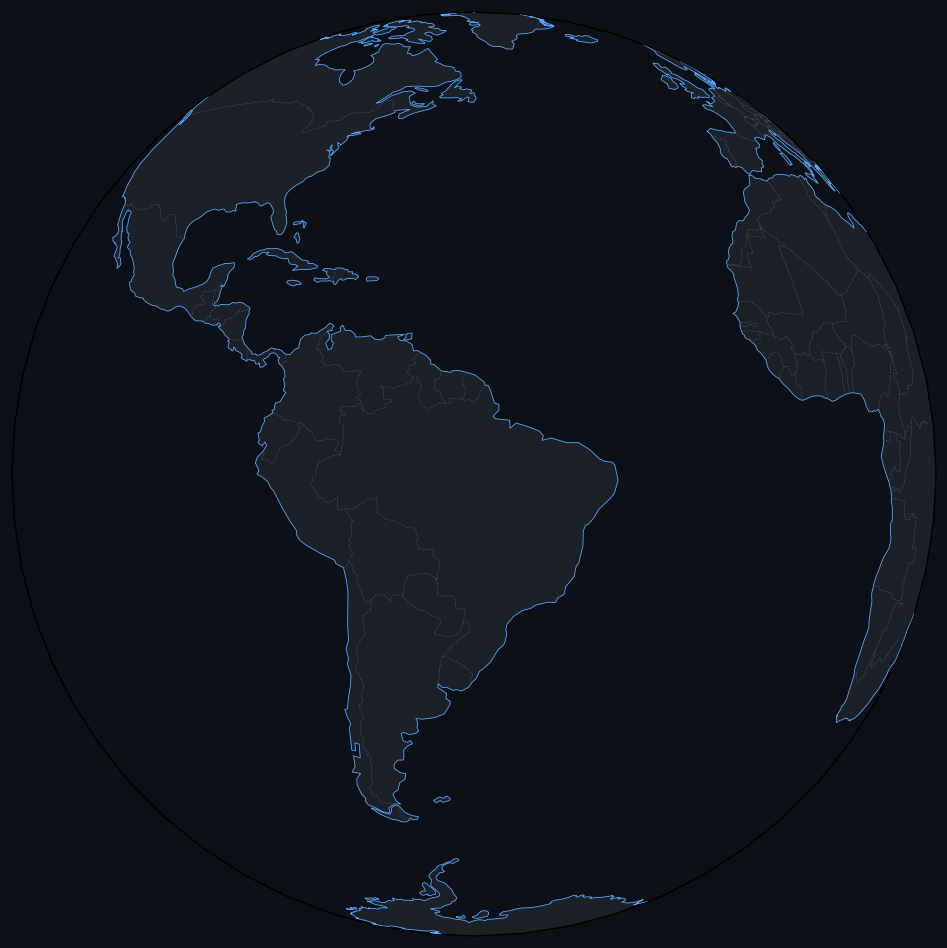

In [25]:
anim = OrthoAnimator(data._ds, "r2")
anim.set_output("northeast_4k.mp4")
anim.set_quality("hd")
anim.set_codec("libx264")
anim.set_rotation(lon_start=-60, lon_end=-35, lat_start=-5, lat_end=-12)
anim.set_rotation_stop(fraction=0.7)
anim.set_fps(15)

anim.set_annotate("Juazeiro - BA %d°C",  pos=(-9.4,   -40.5))
#anim.set_annotate("Recife %d°C",         pos=(-8.05,  -34.88), color="#58a6ff")
anim.set_annotate("Fortaleza %d°C",      pos=(-3.72,  -38.54), color="#58a6ff")
anim.set_annotate("Northeast Brazil",    pos=(-7.5,   -38.0),  interpolate=False, weight="normal", size=8, alpha=0.5, bbox=False)
anim.set_annotate("Manaus %d°C",    pos=(-3.10,  -60.02))
anim.set_annotate("Brasília %d°C",  pos=(-15.78, -47.93))
anim.animate()

In [22]:
data.get_variable_names()

{'time': '',
 'latitude': '',
 'longitude': '',
 'prmsl': 'Pressure reduced to MSL',
 'forecast_hour': '',
 'prate': 'Precipitation rate',
 'r2': '2 metre relative humidity',
 'cwat': 'Cloud water',
 't2m': '2 metre temperature'}